# Classificação de Grãos de Trigo — Seeds Dataset

FIAP 1TIAOA — Fase 4 Cap 3 (IR ALÉM)

Objetivo: aplicar CRISP-DM e Scikit-learn para classificar variedades de trigo (Kama, Rosa e Canadian) usando medidas morfológicas dos grãos.

## 1. Business Understanding

Cooperativas agrícolas precisam classificar grãos com consistência para reduzir erro humano, acelerar triagem e apoiar decisões sobre armazenamento, venda e controle de qualidade. O problema foi modelado como classificação multiclasse.

In [1]:
import json
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

DATA_PATH = Path('data/seeds.csv')
if not DATA_PATH.exists():
    DATA_PATH = Path('..') / 'data' / 'seeds.csv'
df = pd.read_csv(DATA_PATH)
df.head()

,area,perimeter,compactness,length_kernel,width_kernel,asymmetry,groove_length,variety
0,15.26,14.84,0.8710,5.763,3.312,2.221,5.220,1
1,14.88,14.57,0.8811,5.554,3.333,1.018,4.956,1
2,14.29,14.09,0.9050,5.291,3.337,2.699,4.825,1
3,13.84,13.94,0.8955,5.324,3.379,2.259,4.805,1
4,16.14,14.99,0.9034,5.658,3.562,1.355,5.175,1


## 2. Data Understanding

O dataset tem 210 amostras e 7 variáveis explicativas: área, perímetro, compactação, comprimento do kernel, largura do kernel, assimetria e comprimento do sulco. A variável alvo é `variety`, com três classes.

In [2]:
df.shape, df.dtypes

((210, 8),
 area             float64
 perimeter        float64
 compactness      float64
 length_kernel    float64
 width_kernel     float64
 asymmetry        float64
 groove_length    float64
 variety            int64
 dtype: object)

In [3]:
df.describe()

,area,perimeter,compactness,length_kernel,width_kernel,asymmetry,groove_length,variety
count,210.000000,210.000000,210.000000,210.000000,210.000000,210.000000,210.000000,210.000000
mean,14.847524,14.559286,0.870999,5.628533,3.258605,3.700201,5.408071,2.000000
std,2.909699,1.305959,0.023629,0.443063,0.377714,1.503557,0.491480,0.818448
min,10.590000,12.410000,0.808100,4.899000,2.630000,0.765100,4.519000,1.000000
25%,12.270000,13.450000,0.856900,5.262250,2.944000,2.561500,5.045000,1.000000
50%,14.355000,14.320000,0.873450,5.523500,3.237000,3.599000,5.223000,2.000000
75%,17.305000,15.715000,0.887775,5.979750,3.561750,4.768750,5.877000,3.000000
max,21.180000,17.250000,0.918300,6.675000,4.033000,8.456000,6.550000,3.000000


In [4]:
df.isna().sum()

area             0
perimeter        0
compactness      0
length_kernel    0
width_kernel     0
asymmetry        0
groove_length    0
variety          0
dtype: int64

## 3. Visualizações de EDA

As visualizações abaixo ajudam a enxergar distribuição, outliers e separação entre variedades.

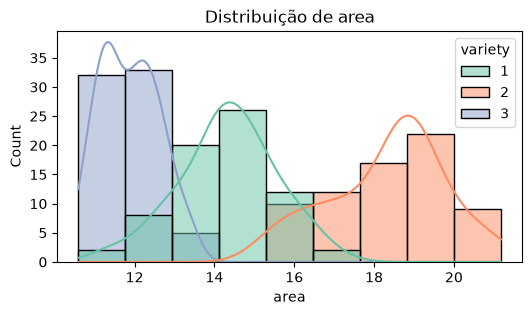

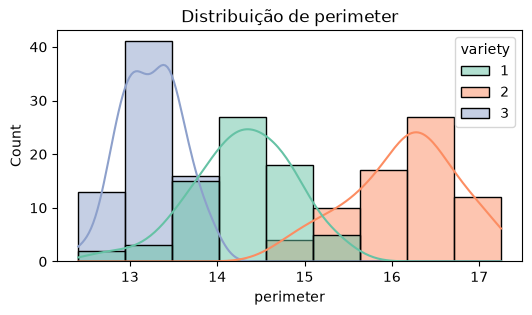

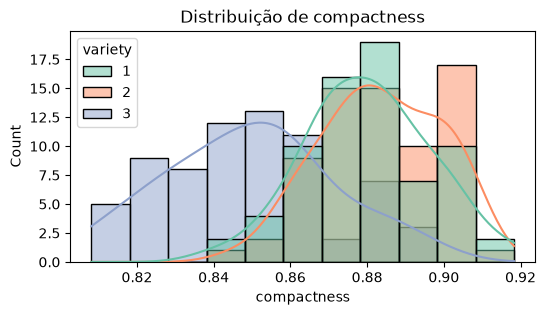

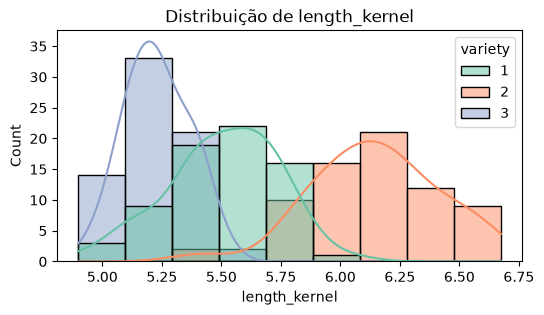

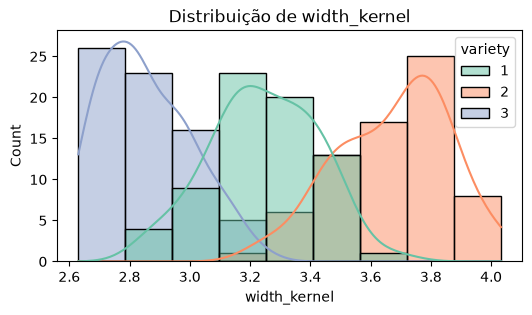

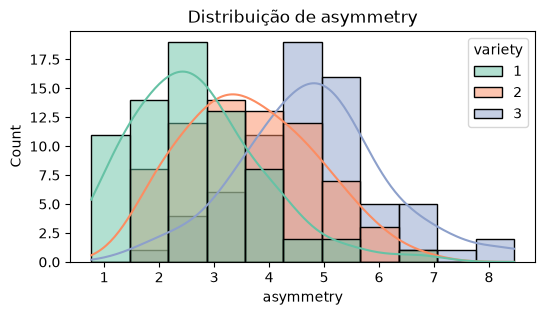

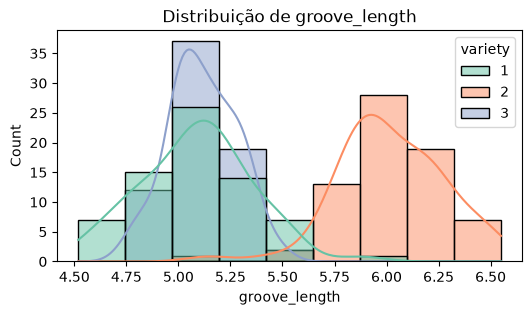

In [5]:
features = ['area','perimeter','compactness','length_kernel','width_kernel','asymmetry','groove_length']
class_names = {1: 'Kama', 2: 'Rosa', 3: 'Canadian'}

for col in features:
    plt.figure(figsize=(6, 3))
    sns.histplot(data=df, x=col, hue='variety', kde=True, palette='Set2')
    plt.title(f'Distribuição de {col}')
    plt.show()

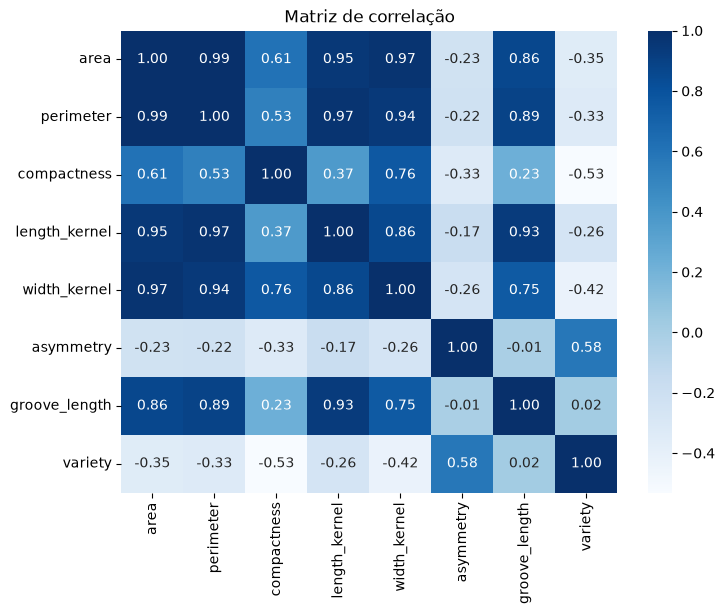

In [6]:
plt.figure(figsize=(8, 6))
sns.heatmap(df[features + ['variety']].corr(), annot=True, cmap='Blues', fmt='.2f')
plt.title('Matriz de correlação')
plt.show()

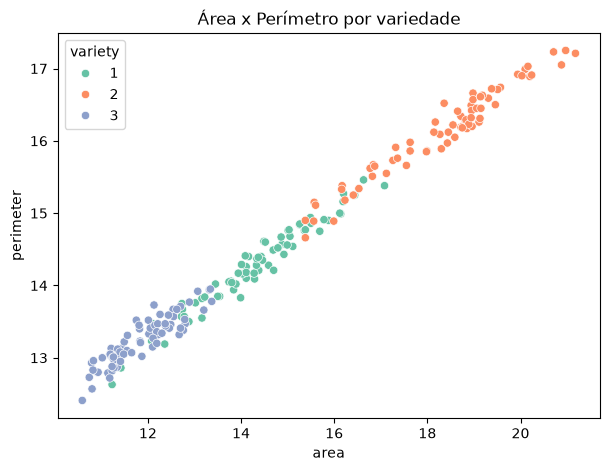

In [7]:
plt.figure(figsize=(7, 5))
sns.scatterplot(data=df, x='area', y='perimeter', hue='variety', palette='Set2')
plt.title('Área x Perímetro por variedade')
plt.show()

## 4. Data Preparation

Foi usado split estratificado 70/30. Os modelos foram avaliados dentro de `Pipeline` com `StandardScaler`, mantendo o mesmo pré-processamento para comparação justa.

In [8]:
X = df[features]
y = df['variety']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

X_train.shape, X_test.shape

((147, 7), (63, 7))

## 5. Modeling

Foram comparados cinco classificadores: KNN, SVM, Random Forest, Naive Bayes e Regressão Logística. O enunciado exigia pelo menos três modelos; usamos cinco para ter comparação mais forte.

In [9]:
candidates = {
    'knn': KNeighborsClassifier(),
    'svm': SVC(kernel='rbf'),
    'random_forest': RandomForestClassifier(random_state=42),
    'naive_bayes': GaussianNB(),
    'logistic_regression': LogisticRegression(max_iter=2000, random_state=42),
}

rows = []
fitted = {}
for name, estimator in candidates.items():
    pipe = Pipeline([('scaler', StandardScaler()), ('clf', estimator)])
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)
    fitted[name] = pipe
    rows.append({
        'model': name,
        'accuracy': accuracy_score(y_test, preds),
        'precision': precision_score(y_test, preds, average='weighted'),
        'recall': recall_score(y_test, preds, average='weighted'),
        'f1': f1_score(y_test, preds, average='weighted'),
    })

comparison = pd.DataFrame(rows).sort_values('f1', ascending=False)
comparison

,model,accuracy,precision,recall,f1
2,random_forest,0.920635,0.923942,0.920635,0.919170
0,knn,0.873016,0.872144,0.873016,0.871284
1,svm,0.873016,0.872144,0.873016,0.871284
4,logistic_regression,0.857143,0.857143,0.857143,0.854294
3,naive_bayes,0.825397,0.833928,0.825397,0.825060


## 6. Tuning

O melhor modelo inicial foi ajustado com GridSearchCV. No pipeline executado, o Random Forest ficou como melhor modelo.

In [10]:
best_name = comparison.iloc[0]['model']
best_pipe = fitted[best_name]

param_grid = {'clf__n_estimators': [80, 120, 200]} if best_name == 'random_forest' else {}

if param_grid:
    grid = GridSearchCV(best_pipe, param_grid, cv=3)
    grid.fit(X_train, y_train)
    best_pipe = grid.best_estimator_
    print('Melhores parâmetros:', grid.best_params_)

preds = best_pipe.predict(X_test)
print(classification_report(y_test, preds, target_names=[class_names[i] for i in sorted(class_names)]))

Melhores parâmetros: {'clf__n_estimators': 80}
              precision    recall  f1-score   support

        Kama       0.94      0.81      0.87        21
        Rosa       0.95      0.95      0.95        21
    Canadian       0.88      1.00      0.93        21

    accuracy                           0.92        63
   macro avg       0.92      0.92      0.92        63
weighted avg       0.92      0.92      0.92        63



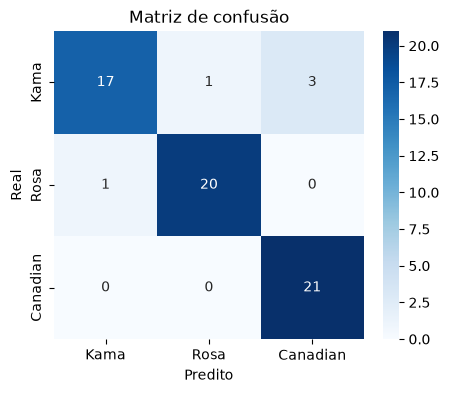

In [11]:
cm = confusion_matrix(y_test, preds)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names.values(), yticklabels=class_names.values())
plt.xlabel('Predito')
plt.ylabel('Real')
plt.title('Matriz de confusão')
plt.show()

## 7. Evaluation

Resultado registrado pelo pipeline:

- Melhor modelo: `random_forest`
- Acurácia: 0.9206
- Precisão ponderada: 0.9239
- Recall ponderado: 0.9206
- F1 ponderado: 0.9192

A matriz de confusão mostra desempenho muito forte em Canadian e Rosa, com maior dificuldade relativa na classe Kama.

## 8. Conclusão e próximos passos

O modelo é adequado como protótipo para triagem de grãos em cooperativas, mas ainda precisa de validação com dados reais antes de produção. Próximos passos: coletar novas safras, testar validação cruzada, criar interface de classificação e monitorar erros por lote.